<a href="https://colab.research.google.com/github/Harpreet-Singh-Learner/Learning-ML/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   sno  Temperature  Pressure
0    1            0    0.0002
1    2           20    0.0012
2    3           40    0.0060
3    4           60    0.0300
4    5           80    0.0900
5    6          100    0.2700
LinearRegression()


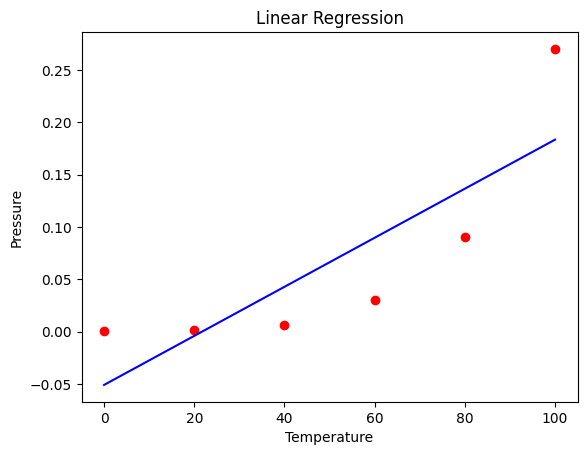

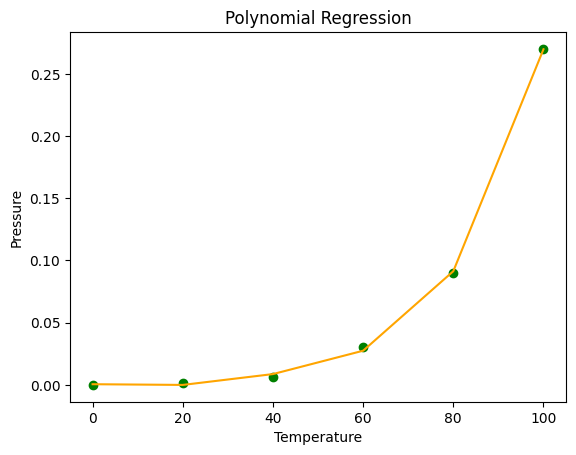

[0.0017591]


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

# Load data from an Excel file
datas = pd.read_excel('/content/data (1).xlsx')
print(datas)

# Separate features (X) and target (y)
X = datas.iloc[:,1:2].values # Features (Temperature)
y = datas.iloc[:,2].values # Target (Pressure)

# First model: Linear Regression
model= LinearRegression()
model.fit(X,y) # Train the linear model

# Second model: Polynomial Regression
poly = PolynomialFeatures(degree=4) # Define polynomial features with degree 4
X_poly = poly.fit_transform(X) # Transform X into polynomial features

model2 = LinearRegression()
print(model2.fit(X_poly,y)) # Train the polynomial model

# Step 6: Visualizing the Linear Regression Results
plt.scatter(X,y,color = 'red') # Plot actual data points
plt.plot(X,model.predict(X), color = 'blue') # Plot linear regression line
plt.title('Linear Regression')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.show()

# Step 7: Visualize the Polynomial Regression Results
plt.scatter(X,y,color = 'green') # Plot actual data points
plt.plot(X,model2.predict(poly.fit_transform(X)), color = "orange") # Plot polynomial regression curve

plt.title('Polynomial Regression')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.show()

# Predict a new value (e.g., Temperature 25) using the polynomial model
print(model2.predict(poly.fit_transform([[25]])))

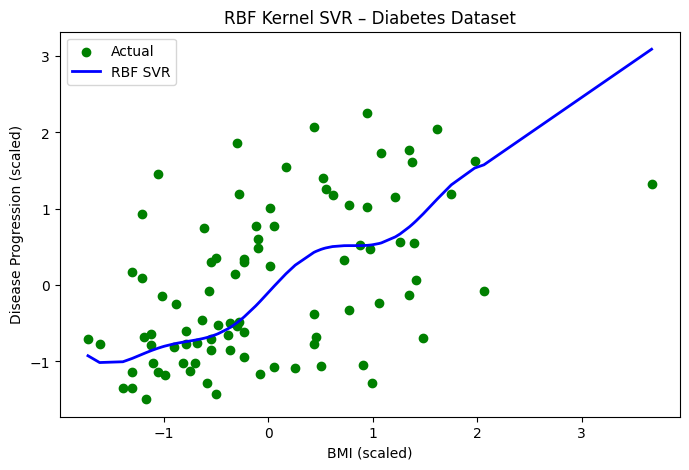

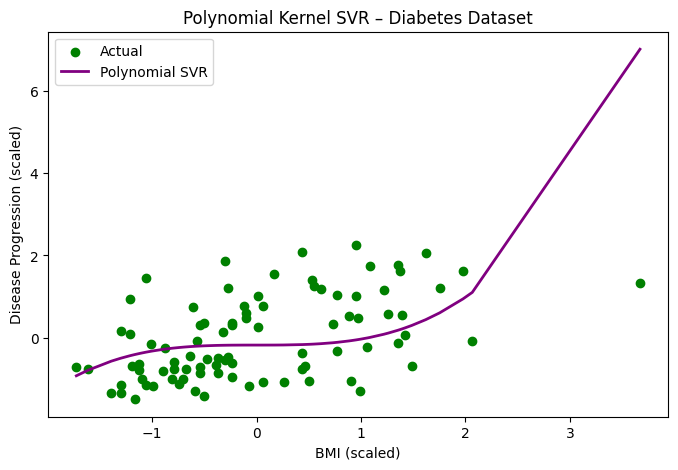

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error # Imported but not used in this specific cell's output

# Load the diabetes dataset
data = load_diabetes()
X = data.data # Features
y= data.target # Target variable
X= X[:,2].reshape(-1,1) # Select only the 3rd feature (Body Mass Index - BMI) and reshape to 2D

# Split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

# Initialize StandardScaler for features (X) and target (y)
Scaler_x = StandardScaler()
Scaler_y = StandardScaler()

# Scale features (X_train, X_test)
X_train = Scaler_x.fit_transform(X_train)
X_test = Scaler_x.fit_transform(X_test)

# Scale target variable (y_train, y_test)
# Note: Scaler_x is used for y, typically Scaler_y would be used for the target variable
y_train =Scaler_x.fit_transform(y_train.reshape(-1,1)).ravel()
y_test = Scaler_x.fit_transform(y_test.reshape(-1,1)).ravel()


# Train Linear Kernel SVR model
svr_linear = SVR(kernel='linear', C=100, epsilon = 0.1)
svr_linear.fit(X_train, y_train)
y_pred_linear = svr_linear.predict(X_test)


# Train RBF (Radial Basis Function) Kernel SVR model
svr_rbf = SVR(kernel = "rbf", C=100, gamma = 0.5, epsilon = 0.1)
svr_rbf.fit(X_train,y_train)
y_pred_rbf = svr_rbf.predict(X_test)

# Train Polynomial Kernel SVR model
svr_poly = SVR(kernel='poly', C=100, degree=3, epsilon=0.1)
svr_poly.fit(X_train, y_train)
y_pred_poly = svr_poly.predict(X_test)

# Sort Test Data for smoother plotting of regression lines
sorted_idx = np.argsort(X_test[:, 0]) # Get indices that would sort X_test by its first column
X_test_sorted = X_test[sorted_idx]
y_test_sorted = y_test[sorted_idx]
y_pred_linear_sorted = y_pred_linear[sorted_idx]
y_pred_rbf_sorted = y_pred_rbf[sorted_idx]
y_pred_poly_sorted = y_pred_poly[sorted_idx]


# Plot RBF Kernel SVR Results
plt.figure(figsize=(8, 5))
plt.scatter(X_test_sorted, y_test_sorted, color='green', label='Actual') # Plot actual test data points
plt.plot(X_test_sorted, y_pred_rbf_sorted, color='blue', linewidth=2, label='RBF SVR') # Plot the RBF SVR regression line
plt.title("RBF Kernel SVR – Diabetes Dataset")
plt.xlabel("BMI (scaled)")
plt.ylabel("Disease Progression (scaled)")
plt.legend()
plt.show()

# Plot Polynomial Kernel SVR Results
plt.figure(figsize=(8, 5))
plt.scatter(X_test_sorted, y_test_sorted, color='green', label='Actual') # Plot actual test data points
plt.plot(X_test_sorted, y_pred_poly_sorted, color='purple', linewidth=2, label='Polynomial SVR') # Plot the Polynomial SVR regression line
plt.title("Polynomial Kernel SVR – Diabetes Dataset")
plt.xlabel("BMI (scaled)")
plt.ylabel("Disease Progression (scaled)")
plt.legend()
plt.show()

This code cell implements Support Vector Regression (SVR) using two different kernel functions: linear and Radial Basis Function (RBF). It uses the Diabetes dataset to predict disease progression based on a single feature (BMI).

### 1. Import Libraries

This section imports all the necessary Python libraries for data manipulation, machine learning (SVR, StandardScaler, train_test_split), and plotting.

In [ ]:
# Import necessary libraries for data preprocessing, SVR model, data loading, splitting, and plotting
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

### 2. Load and Prepare Data

Here, the `load_diabetes()` dataset from scikit-learn is loaded. For this example, only the third feature (Body Mass Index - BMI) is selected as the independent variable `X`, and the target variable `y` is the disease progression. The selected feature `X` is reshaped to be a 2D array, which is required by scikit-learn models.

In [ ]:
# Load the diabetes dataset from scikit-learn
data = load_diabetes()
X = data.data # Extract features from the dataset
y= data.target # Extract the target variable (disease progression)
X= X[:,2].reshape(-1,1) # Select the 3rd feature (BMI) and reshape it into a 2D array, as required by scikit-learn models

### 3. Split Data into Training and Testing Sets

The dataset is divided into training and testing sets using `train_test_split`. 80% of the data is used for training the model, and 20% is reserved for evaluating its performance. `random_state` ensures reproducibility of the split.

In [ ]:
# Split the dataset into training and testing sets
# X: features, y: target
# test_size=0.2: 20% of the data will be used for testing, 80% for training
# random_state=42: Ensures the split is reproducible, so you get the same train/test sets every time
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

### 4. Scale Features and Target Variable

Support Vector Machines (and SVR) are sensitive to the scale of the input data. `StandardScaler` is used to transform the features (`X`) and the target (`y`) so that they have zero mean and unit variance. This step is crucial for optimal model performance. The target variable `y` is reshaped to a 2D array before scaling and then `ravel()` is used to convert it back to a 1D array after scaling to match the expected format for SVR.

In [ ]:
# Initialize StandardScaler objects for scaling features (X) and target (y)
Scaler_x = StandardScaler()
Scaler_y = StandardScaler()

# Fit the scaler to the training features and then transform both training and test features
X_train = Scaler_x.fit_transform(X_train)
X_test = Scaler_x.fit_transform(X_test)

# Reshape y_train and y_test to 2D arrays, fit the scaler (Scaler_x in this case) and transform, then flatten back to 1D
# Note: It's generally recommended to use a separate scaler (like Scaler_y) for the target variable if its distribution is different from features.
y_train =Scaler_x.fit_transform(y_train.reshape(-1,1)).ravel()
y_test = Scaler_x.fit_transform(y_test.reshape(-1,1)).ravel()

### 5. Train SVR Models (Linear and RBF Kernels)

Two SVR models are trained: one with a 'linear' kernel and another with an 'rbf' (Radial Basis Function) kernel. The `C` parameter controls the penalty of the error term, and `epsilon` defines the margin of tolerance where no penalty is given to errors. For the RBF kernel, `gamma` defines how far the influence of a single training example reaches, with low values meaning 'far' and high values meaning 'close'.

In [ ]:
# Train Linear Kernel SVR (Support Vector Regressor) model
# kernel='linear': Uses a linear function as the kernel
# C=100: Regularization parameter, controls the penalty for errors
# epsilon=0.1: Defines the margin of tolerance where no penalty is given to errors
svr_linear = SVR(kernel='linear', C=100, epsilon = 0.1)
svr_linear.fit(X_train, y_train)
y_pred_linear = svr_linear.predict(X_test) # Make predictions on the test set


# Train RBF (Radial Basis Function) Kernel SVR model
# kernel='rbf': Uses an RBF function as the kernel, suitable for non-linear relationships
# gamma=0.5: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'. Defines how much influence a single training example has.
svr_rbf = SVR(kernel = "rbf", C=100, gamma = 0.5, epsilon = 0.1)
svr_rbf.fit(X_train,y_train)
y_pred_rbf = svr_rbf.predict(X_test) # Make predictions on the test set

### 6. Sort Test Data for Visualization

To create a smooth regression line in the plot, the test data (`X_test`, `y_test`) and their corresponding predictions (`y_pred_linear`, `y_pred_rbf`) are sorted based on the values of `X_test`. This ensures that when plotted, the line connects points in an ascending order of the independent variable.

In [ ]:
# Sort test data and predictions based on the values of X_test
# This is done to ensure a smooth regression line when plotting the results
sorted_idx = np.argsort(X_test[:, 0]) # Get indices that would sort the first (and only) column of X_test
X_test_sorted = X_test[sorted_idx]
y_test_sorted = y_test[sorted_idx]
y_pred_linear_sorted = y_pred_linear[sorted_idx]
y_pred_rbf_sorted = y_pred_rbf[sorted_idx]
y_pred_poly_sorted = y_pred_poly[sorted_idx]

### 7. Visualize RBF Kernel SVR Results

This section uses `matplotlib.pyplot` to visualize the performance of the RBF SVR model. It plots the actual test data points as a scatter plot and the RBF SVR's predictions as a continuous line. This helps in understanding how well the model captures the underlying pattern in the data.

In [ ]:
# Create a new figure for the RBF SVR plot
plt.figure(figsize=(8, 5))
# Plot actual test data points as a scatter plot
plt.scatter(X_test_sorted, y_test_sorted, color='green', label='Actual')
# Plot the RBF SVR regression line
plt.plot(X_test_sorted, y_pred_rbf_sorted, color='blue', linewidth=2, label='RBF SVR')
# Set plot title and labels
plt.title("RBF Kernel SVR – Diabetes Dataset")
plt.xlabel("BMI (scaled)")
plt.ylabel("Disease Progression (scaled)")
plt.legend() # Display the legend to identify plots
plt.show() # Show the plot

### Explanation of Functions in SVR Code

Here's a detailed look at the functions used in the SVR implementation:

*   **`load_diabetes()`** (from `sklearn.datasets`):
    *   **Purpose:** Loads and returns the diabetes dataset (a popular dataset for regression tasks). It's a convenient way to get a pre-processed dataset for machine learning experiments.
    *   **Returns:** A dictionary-like object (Bunch) with attributes such as `data` (the feature matrix), `target` (the regression target), and `feature_names`.

*   **`reshape(-1, 1)`** (NumPy array method):
    *   **Purpose:** Reshapes an array. The `-1` argument tells NumPy to automatically calculate the dimension size for that axis, and `1` specifies that we want a single column. This is crucial for `sklearn` models, which typically expect a 2D array for features (even if it's just one feature).
    *   **Example:** If you have a 1D array `[1, 2, 3]`, `reshape(-1, 1)` turns it into `[[1], [2], [3]]`.

*   **`train_test_split()`** (from `sklearn.model_selection`):
    *   **Purpose:** Splits arrays or matrices into random train and test subsets. This is a fundamental step in machine learning to evaluate a model's performance on unseen data.
    *   **Parameters:**
        *   `*arrays`: The arrays to be split (e.g., `X`, `y`).
        *   `test_size`: (e.g., `0.2`) Represents the proportion of the dataset to include in the test split.
        *   `random_state`: (e.g., `42`) Controls the shuffling applied to the data before applying the split. An integer value ensures reproducibility.

*   **`StandardScaler()`** (from `sklearn.preprocessing`):
    *   **Purpose:** Standardizes features by removing the mean and scaling to unit variance. This preprocessing step is vital for many machine learning algorithms, including SVR, as they are sensitive to the scale of input data.
    *   **Methods:**
        *   `fit(data)`: Computes the mean and standard deviation to be used for later scaling.
        *   `transform(data)`: Performs the scaling using the parameters learned by `fit()`.
        *   `fit_transform(data)`: A convenience method that first `fits` and then `transforms` the data.

*   **`ravel()`** (NumPy array method):
    *   **Purpose:** Returns a contiguous flattened array (1D array). After `StandardScaler` transforms a 2D array, if the target variable `y` was 2D, it might still be 2D. `ravel()` converts it back to a 1D array, which is usually the expected format for target variables in `sklearn` regression models.

*   **`SVR()`** (from `sklearn.svm`):
    *   **Purpose:** Implements Support Vector Regression. It constructs a hyperplane or set of hyperplanes in a high or infinite-dimensional space, which can be used for regression.
    *   **Parameters:**
        *   `kernel`: Specifies the kernel type to be used in the algorithm (e.g., `'linear'`, `'rbf'`, `'poly'`, `'sigmoid'`). The choice of kernel significantly impacts the model's ability to capture non-linear relationships.
        *   `C`: Regularization parameter. The strength of the regularization is inversely proportional to `C`. Smaller `C` values encourage a wider margin, allowing more training errors, while larger `C` values aim for a narrower margin, penalizing errors more strictly.
        *   `epsilon`: Epsilon in the epsilon-SVR model. It specifies the epsilon-tube within which no penalty is associated with errors. A larger epsilon means more points can be within the tube without penalty, leading to a simpler model.
        *   `gamma`: Kernel coefficient for 'rbf', 'poly', and 'sigmoid' kernels. It defines how much influence a single training example has. Small `gamma` means a large influence, and large `gamma` means a small influence.
    *   **Methods:**
        *   `fit(X_train, y_train)`: Trains the SVR model using the training data.
        *   `predict(X_test)`: Predicts target values for the given `X_test`.

*   **`np.argsort()`** (from `numpy`):
    *   **Purpose:** Returns the indices that would sort an array. This is used here to get the order of indices that would sort `X_test`, which is then used to sort `X_test`, `y_test`, and the predictions for a smooth plot.

*   **`plt.figure()`** (from `matplotlib.pyplot`):
    *   **Purpose:** Creates a new figure, or activates an existing figure.
    *   **Parameter:** `figsize` (e.g., `(8, 5)`) specifies the width and height of the figure in inches.

*   **`plt.scatter()`** (from `matplotlib.pyplot`):
    *   **Purpose:** Creates a scatter plot of `y` versus `x` with varying marker size and color.
    *   **Parameters:**
        *   `x`, `y`: The data positions.
        *   `color`: The color of the markers.
        *   `label`: The label for this dataset, used in the legend.

*   **`plt.plot()`** (from `matplotlib.pyplot`):
    *   **Purpose:** Plots `y` versus `x` as lines and/or markers.
    *   **Parameters:**
        *   `x`, `y`: The horizontal and vertical coordinates of the data points.
        *   `color`: The color of the line.
        *   `linewidth`: The width of the line.
        *   `label`: The label for this line, used in the legend.

*   **`plt.title()`, `plt.xlabel()`, `plt.ylabel()`** (from `matplotlib.pyplot`):
    *   **Purpose:** Sets the title of the current axes, the label for the x-axis, and the label for the y-axis, respectively.

*   **`plt.legend()`** (from `matplotlib.pyplot`):
    *   **Purpose:** Places a legend on the axes, using the `label` arguments from `plt.scatter()` and `plt.plot()`.

*   **`plt.show()`** (from `matplotlib.pyplot`):
    *   **Purpose:** Displays all open figures. This is necessary to render the plots.

In [ ]:
from google.colab import drive
# Mount Google Drive to allow access to files stored in Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


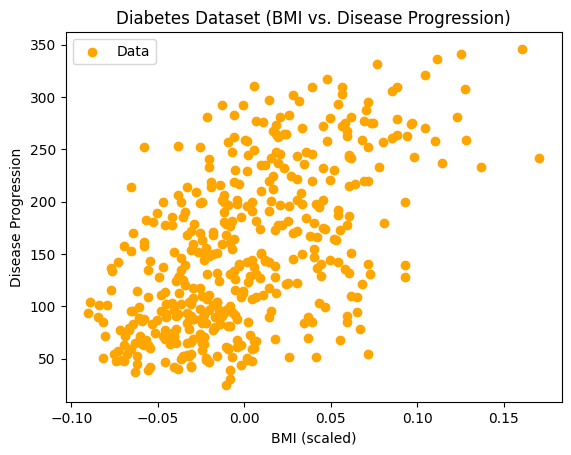

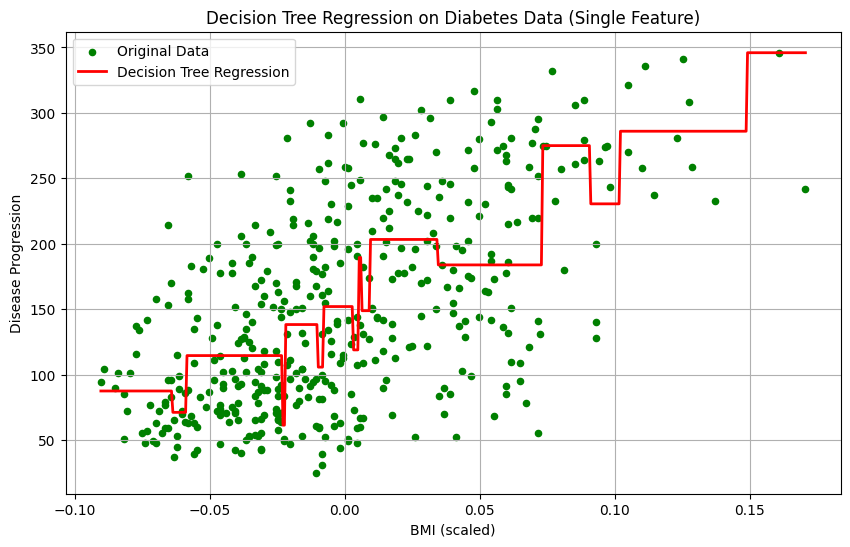

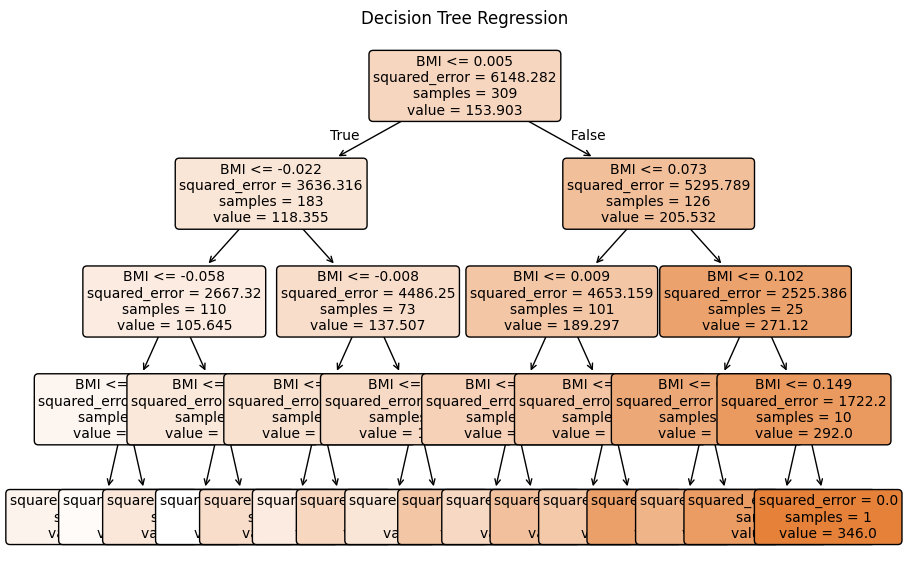

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor , export_text # export_text is for visualizing text representation of tree
from sklearn.metrics import mean_squared_error # Imported but not directly used for printing evaluation
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree # For visualizing the decision tree structure
from sklearn.datasets import load_diabetes
data = load_diabetes()
X = data.data
y = data.target

# Fix: Select only one feature for X (e.g., the 3rd feature, BMI, as in the SVR example)
X = X[:, 2].reshape(-1, 1)

# Plot the data for the selected single feature
plt.scatter(X, y, color="orange", label="Data") # Changed to scatter plot for single feature
plt.title("Diabetes Dataset (BMI vs. Disease Progression)") # Updated title
plt.xlabel("BMI (scaled)") # Updated label
plt.ylabel("Disease Progression") # Updated label
plt.legend()
plt.show()

# Split the synthetic data into training and testing sets (70% train, 30% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Initialize and train a Decision Tree Regressor model
model = DecisionTreeRegressor(max_depth = 4 , random_state = 42) # Limiting max_depth to 4 to prevent overfitting and for clearer visualization
model.fit(X_train,Y_train)

# Create a fine range of X values spanning the original data for a smoother prediction plot
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_pred_plot = model.predict(X_plot)

# Sort X_test and y_pred (though y_pred is not directly used from X_test in the plot below, y_pred_plot is used)
sorted_idx_test = np.argsort(X_test.flatten())
X_test_sorted = X_test[sorted_idx_test]
# Note: y_pred was not defined in the original code for X_test directly, the line plot uses y_pred_plot.
# If you wanted to plot predictions for X_test, you would do:
# y_pred = model.predict(X_test)
# y_pred_sorted = y_pred[sorted_idx_test]

# Plot the Decision Tree Regression results
plt.figure(figsize = (10,6))
plt.scatter(X,y, color = "green", label = "Original Data", s=20) # Plot original data points
plt.plot(X_plot, y_pred_plot, color = "red", label = "Decision Tree Regression", linewidth=2) # Plot the smooth prediction line
plt.xlabel("BMI (scaled)") # Updated label
plt.ylabel("Disease Progression") # Updated label
plt.title("Decision Tree Regression on Diabetes Data (Single Feature)") # Updated title
plt.legend()
plt.grid(True) # Add grid for clarity
plt.show()


# Plot the Decision Tree structure for visualization
plt.figure(figsize = (10,7))
plot_tree(
    model,
    feature_names = ["BMI"], # Name for the feature(s) - updated to reflect BMI
    filled = True, # Fill nodes with colors to indicate their values/classes
    rounded = True, # Round node corners for better aesthetics
    fontsize = 10) # Set font size for text in the tree nodes
plt.title("Decision Tree Regression")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score

# Load the California housing dataset
Dta = fetch_california_housing()
# Convert the dataset features into a pandas DataFrame
data_housing = pd.DataFrame(Dta.data, columns = Dta.feature_names)
data_housing["target"] = Dta.target # Add the target variable (house price) to the DataFrame

# Separate features (X) and target (y)
X= data_housing.drop("target", axis = 1) # X contains all features except 'target'
y = data_housing["target"] # y contains only the 'target' variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, Y_train , Y_test = train_test_split(X,y,test_size = 0.2, random_state =42)

# Initialize and train a Random Forest Regressor model
model = RandomForestRegressor(n_estimators = 100) # Use 100 decision trees in the forest
model.fit(X_train , Y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the R-squared score to evaluate model performance
print(r2_score(Y_test, y_pred))

0.8072202242980513


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score , recall_score
from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data # Features of the dataset
y = data.target # Target variable (0 for malignant, 1 for benign)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size = 0.20 , random_state = 0)

# Initialize and apply StandardScaler for feature scaling
# Scaling is crucial for many machine learning algorithms, including Logistic Regression, for optimal performance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fit scaler on training data and transform it
X_test = scaler.transform(X_test) # Transform test data using the scaler fitted on training data

# Initialize and train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train , y_train)

# Make predictions on the scaled test set
y_pred = model.predict(X_test)

# Print evaluation metrics for the classification model
print(accuracy_score(y_test, y_pred)) # Overall accuracy of the model
print(confusion_matrix(y_test, y_pred)) # Confusion matrix showing true positives, true negatives, false positives, false negatives
print(precision_score(y_test, y_pred)) # Precision of the model
print(recall_score(y_test, y_pred)) # Recall of the model

0.956140350877193
[[44  3]
 [ 2 65]]
0.9558823529411765
0.9701492537313433
